# Load USGS variometer station locations on a map

Import packages:

In [15]:
from pyspedas.tplot_tools.MPLPlotter.tplot_map import tplot_map, tplot_trace_tvars_to_tmap, add_markers, add_station_fovs
from pyspedas.projects.themis import state
from pyspedas.projects.themis.ground import gmag
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

Initialize Tplot_Map object:

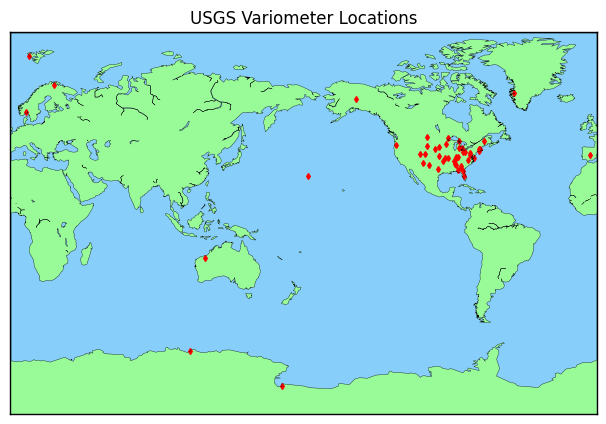

In [31]:
fig=plt.figure(figsize=(8,4.5))
ax = fig.add_axes([0.05,0.05,0.9,0.85])

# mercator/2D map 
tmap = tplot_map(llcrnrlon=0,llcrnrlat=-85,urcrnrlon=360,urcrnrlat=85,projection='mill')
tmap._params.drawmapboundary = {"fill_color":"lightskyblue"}
tmap._params.fillcontinents = {"color":"palegreen","lake_color":"lightskyblue"}

# Add ground station markers
themis_gmag_dict = gmag.Themis_gmag()
for station_dict in themis_gmag_dict.get_gmag_list():
    if station_dict['variom'] == 'Y':
        tmap = add_markers(coords=np.array([0,float(station_dict['lat']),float(station_dict['lng'])]),tmap=tmap,label=station_dict['ccode'],ms=3)

tmap.add_map_boundary()
tmap.add_fillcontinents()
tmap.add_coastlines(linewidth=0.25)
#date_str = '2026-02-03'
#tmap.add_nightshade(date=dt.datetime.strptime(date_str+" 15:00:00",'%Y-%m-%d %H:%M:%S'))
plt.title("USGS Variometer Locations")
#ax.legend()
plt.show()


# Plot trace footpaths alongside variometer station markers 

Import packages:

In [37]:
from pyspedas.tplot_tools.MPLPlotter.tplot_map import tplot_map, tplot_trace_tvars_to_tmap, add_markers, add_station_fovs, tvar_to_foottracks, add_tracks
from pyspedas.projects.themis import state
from pyspedas.projects.themis.ground import gmag
import datetime as dt
import numpy as np

Create tplot variables THEMIS A and THEMIS D positional data:

In [38]:
date_str = '2026-01-20'
state(trange=[date_str,date_str], probe='a')
state(trange=[date_str,date_str], probe='d')

24-Jun-26 19:28:56: File is current: themis_data/tha/l1/state/2026/tha_l1_state_20260120.cdf
24-Jun-26 19:28:57: File is current: themis_data/thd/l1/state/2026/thd_l1_state_20260120.cdf


['thd_pos',
 'thd_vel',
 'thd_spin_initial_delta_phi',
 'thd_spin_idpu_spinper',
 'thd_spin_segflags',
 'thd_spin_ecl_initial_delta_phi',
 'thd_spin_ecl_idpu_spinper',
 'thd_spin_ecl_segflags',
 'thd_pos_gse',
 'thd_pos_gsm',
 'thd_vel_gse',
 'thd_vel_gsm',
 'thd_pos_sel',
 'thd_pos_sse',
 'thd_vel_sel',
 'thd_vel_sse']

Compute traces:

In [39]:
trace_a = tvar_to_foottracks(tvar_to_trace = 'tha_pos_gsm', model_str = "t89", endpoint = "ionosphere-north")
trace_d = tvar_to_foottracks(tvar_to_trace = 'thd_pos_gsm', model_str = "t89", endpoint = "ionosphere-north")

24-Jun-26 19:29:01: The km parameter is deprecated. Please use units_in, foot_out_units, and trace_out_units instead.
24-Jun-26 19:29:01: Setting units_in, foot_out_units, and trace_out_units to 'km'.
24-Jun-26 19:29:01: Setting units for input_var_re
24-Jun-26 19:29:01: get_t89_parameters: No kp, iopt, or parmod data provided, defaulting to iopt=3
24-Jun-26 19:29:05: Computed 100/1440 traces so far, current trace time 2026-01-20 01:40:00.000000
24-Jun-26 19:29:09: Computed 200/1440 traces so far, current trace time 2026-01-20 03:20:00.000000
24-Jun-26 19:29:12: Computed 300/1440 traces so far, current trace time 2026-01-20 05:00:00.000000
24-Jun-26 19:29:14: Computed 400/1440 traces so far, current trace time 2026-01-20 06:40:00.000000
24-Jun-26 19:29:17: Computed 500/1440 traces so far, current trace time 2026-01-20 08:20:00.000000
24-Jun-26 19:29:22: Computed 600/1440 traces so far, current trace time 2026-01-20 10:00:00.000000
24-Jun-26 19:29:28: Computed 700/1440 traces so far, cu

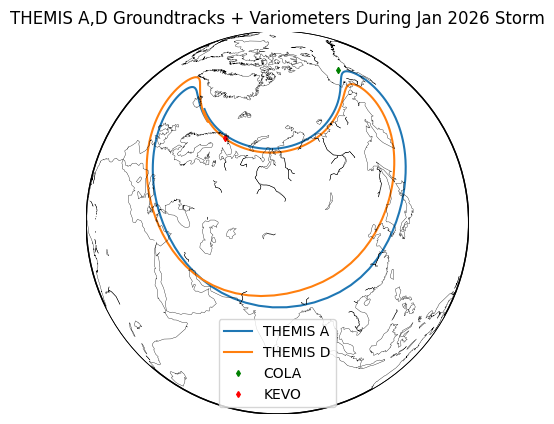

In [ ]:

fig=plt.figure(figsize=(8,4.5))
ax = fig.add_axes([0.05,0.05,0.9,0.85])

# Initialize map:
tmap = tplot_map(lat_0=50,lon_0=80)

# Add ground tracks:
tmap = add_tracks(tmap=tmap, coords=trace_a[0], label = 'THEMIS A')
tmap = add_tracks(tmap=tmap, coords=trace_d[0], label = 'THEMIS D')

# Add ground station markers
themis_gmag_dict = gmag.Themis_gmag()
for station_dict in themis_gmag_dict.get_gmag_list():
    if station_dict['variom'] == 'Y':
        match station_dict['ccode']:
            case "KEVO":
                tmap = add_markers(coords=np.array([0,float(station_dict['lat']),float(station_dict['lng'])]),tmap=tmap,label=station_dict['ccode'],ms=3,color="r")
            case "COLA":
                tmap = add_markers(coords=np.array([0,float(station_dict['lat']),float(station_dict['lng'])]),tmap=tmap,label=station_dict['ccode'],ms=3,color="g")

tmap.add_map_boundary()
tmap.add_fillcontinents()
tmap.add_coastlines(linewidth=0.25)
#tmap.add_nightshade(date=dt.datetime.strptime(date_str+" 12:00:00",'%Y-%m-%d %H:%M:%S'))

plt.title("THEMIS A,D Groundtracks + Variometers During Jan 2026 Storm")
ax.legend()
plt.show()

Plot magnetic field measurements for THEMIS A, D, COLA, and KEVO in the same time period:

In [ ]:
#fig, axs = plt.subplots(ncols=1, nrows=4)
#gs = axs[1, 2].get_gridspec()
## remove the underlying Axes
#for ax in axs[1:, -1]:
#    ax.remove()
#axbig = fig.add_subplot(gs[1:, -1])
#axbig.annotate('Big Axes \nGridSpec[1:, -1]', (0.1, 0.5),
#               xycoords='axes fraction', va='center')
#fig.tight_layout()
